# Deep Ensemble Learning for Brugada Syndrome Screening CNN-LSTM Representation with XGBoost Decision Layer

---

**Challenge:** International Data Science Challenge 2026  
**Theme:** Mathematics for Hope in Healthcare  
**Dataset:** Brugada-HUCA, 12-Lead ECG Recordings (PhysioNet, v1.0.0)  
**Task:** Binary Classification, Brugada Syndrome vs Normal ECG  
**Method:** CNN + LSTM (feature extractor) + XGBoost (classifier) + Focal Loss  

---

### 📋 Table of Contents
1. Install & Import Libraries
2. Load Dataset
3. Load ECG Signals
4. Preprocessing — Normalization
5. Train / Test Split
6. Model Architecture — CNN + LSTM
7. Threshold Finder
8. Cross-Validation (5-Fold)
9. Final Model Training
10. Feature Extraction (CNN → XGBoost)
11. XGBoost Training
12. Final Evaluation
13. Visualization

---

---
## 1. Install & Import Libraries

We install required libraries and import all dependencies upfront.

| Library | Purpose |
|---|---|
| `wfdb` | Read ECG files in WFDB format (.dat / .hea) |
| `xgboost` | Gradient boosting classifier on CNN features |
| `tensorflow` | CNN + LSTM deep learning model |
| `scikit-learn` | Metrics, splitting, cross-validation |
| `matplotlib` | Visualization |


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving brugada-huca-12-lead-ecg-recordings-for-the-study-of-brugada-syndrome-1.0.0.zip to brugada-huca-12-lead-ecg-recordings-for-the-study-of-brugada-syndrome-1.0.0.zip


### 1.2 Extract Dataset

Upload the dataset ZIP file from PhysioNet, then extract it.  
Expected filename: `brugada-huca-12-lead-ecg-recordings-for-the-study-of-brugada-syndrome-1.0.0.zip`

In [ ]:
import zipfile

zip_path = "brugada-huca-12-lead-ecg-recordings-for-the-study-of-brugada-syndrome-1.0.0.zip"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("dataset")

### 1.3 Install Dependencies

In [ ]:
!pip install -q wfdb xgboost

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 98.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.1 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.1 which is incompatible.
db-dtypes 1.5.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.1 which is incompatible.


### 1.4 Import All Libraries

In [ ]:
import numpy as np
import pandas as pd
import wfdb
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    classification_report, accuracy_score,
    roc_auc_score, roc_curve, auc,
    f1_score, precision_recall_curve
)

import tensorflow as tf
tf.get_logger().setLevel('ERROR')

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, LSTM, Dense, Dropout,
    BatchNormalization, Input
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from xgboost import XGBClassifier

print("TF version:", tf.__version__)
print("All imports OK.")

TF version: 2.19.0
All imports OK.


---
## 2. Load Dataset

Load `metadata.csv` which contains diagnostic labels per patient.

**Metadata columns:**

| Column | Description |
|---|---|
| `patient_id` | Unique patient identifier |
| `basal_pattern` | Whether baseline ECG shows Brugada-type pattern (0/1) |
| `sudden_death` | Whether patient experienced sudden cardiac death (0/1) |
| `brugada` | **Main label** — 0 = Normal, 1 = Brugada, 2 = Brugada with basal pattern |


In [ ]:
DATA_PATH = "dataset/brugada-huca-12-lead-ecg-recordings-for-the-study-of-brugada-syndrome-1.0.0"

metadata = pd.read_csv(f"{DATA_PATH}/metadata.csv")
print("Dataset shape:", metadata.shape)
print(metadata['brugada'].value_counts())

Dataset shape: (363, 4)
brugada
0    287
1     69
2      7
Name: count, dtype: int64


---
## 3. Load ECG Signals

We load all 363 ECG recordings using the `wfdb` library.

**Signal specifications:**
- Shape per recording: `(1200 samples, 12 leads)` — 12 seconds × 100 Hz
- Signals are padded or truncated to exactly `TARGET_LEN = 1200` samples
- Final array shape: `(363, 1200, 12)`

Labels are binarized: `brugada > 0 → 1` (Brugada), `brugada == 0 → 0` (Normal).

In [ ]:
TARGET_LEN = 1200

X, y = [], []
for _, row in metadata.iterrows():
    patient_id = str(row['patient_id'])
    record = wfdb.rdrecord(f"{DATA_PATH}/files/{patient_id}/{patient_id}")
    signal = record.p_signal

    if signal.shape[0] > TARGET_LEN:
        signal = signal[:TARGET_LEN, :]
    elif signal.shape[0] < TARGET_LEN:
        signal = np.pad(signal, ((0, TARGET_LEN - signal.shape[0]), (0, 0)), mode='constant')

    X.append(signal)
    y.append(row['brugada'])

X = np.array(X)
y = (np.array(y) > 0).astype(int)

neg, pos = np.bincount(y)
IMBALANCE_RATIO = neg / pos

print(f"Shape X         : {X.shape}")
print(f"Non-Brugada (0) : {neg}")
print(f"Brugada (1)     : {pos}")
print(f"Imbalance ratio : {IMBALANCE_RATIO:.2f}")

Shape X         : (363, 1200, 12)
Non-Brugada (0) : 287
Brugada (1)     : 76
Imbalance ratio : 3.78


---
## 4. Preprocessing — Normalization

We apply **Z-score normalization** per sample (across all leads and timesteps).
```
X_normalized = (X - mean(X)) / (std(X) + ε)
```

This ensures all ECG recordings have comparable amplitude scales,  
regardless of differences in electrode placement or patient physiology.



In [ ]:
# Normalization sample
X = np.array([
    (s - np.mean(s)) / (np.std(s) + 1e-8)
    for s in X
])

---
## 5. Train / Test Split

We split the dataset into training and test sets using **stratified splitting**  
to preserve the Brugada:Normal class ratio in both subsets.

| Subset | Size | Purpose |
|---|---|---|
| **Train** | 80% (N≈290) | Model training and cross-validation |
| **Test** | 20% (N≈73) | Final evaluation  **never touched until Section 12** |


In [ ]:
X_train_all, X_test, y_train_all, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train : {X_train_all.shape[0]} samples {np.bincount(y_train_all)}")
print(f"Test  : {X_test.shape[0]} samples {np.bincount(y_test)}")

Train : 290 samples [229  61]
Test  : 73 samples [58 15]


---
## 6. Model Architecture

### Architecture Overview
```
Input (1200, 12)
    ↓
Conv1D(32, kernel=11) + BatchNorm + MaxPool   ← extract local ECG patterns
    ↓
Conv1D(64, kernel=7)  + BatchNorm + MaxPool   ← higher-level morphology
    ↓
Conv1D(128, kernel=5) + BatchNorm + MaxPool   ← abstract feature maps
    ↓
LSTM(64)                                       ← temporal dependencies
    ↓
Dense(64, relu) + Dropout(0.3)                ← named 'features' layer
    ↓
Dense(1, sigmoid)                             ← Brugada probability
```

### Key Design Decisions

| Component | Choice | Reason |
|---|---|---|
| **Loss function** | Focal Loss (γ=2, α=0.75) | Handles class imbalance better than BCE |
| **L2 Regularization** | `1e-4` on Conv + Dense | Prevents overfitting on small dataset |
| **Dropout** | 0.3 | Additional regularization |
| **EarlyStopping** | patience=7 on val_loss | Stops before overfitting |
| **ReduceLROnPlateau** | factor=0.5, patience=3 | Adaptive learning rate |

### Focal Loss

Focal Loss down-weights easy examples and focuses training on hard, misclassified cases, especially important for the minority Brugada class:
```
FL(p_t) = α_t × (1 - p_t)^γ × CE(p_t)
```
where γ=2 and α=0.75 (higher weight for Brugada class).

In [ ]:
def build_model(input_shape=(1200, 12), gamma=2.0, alpha=0.75):

    def focal_loss_fn(y_true, y_pred):
        y_true  = tf.cast(y_true, tf.float32)
        y_pred  = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        ce      = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)
        p_t     = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
        return tf.reduce_mean(alpha_t * tf.pow(1 - p_t, gamma) * ce)

    inp = Input(shape=input_shape)

    x = Conv1D(32, 11, activation='relu', kernel_regularizer=l2(1e-4))(inp)
    x = BatchNormalization()(x)
    x = MaxPooling1D(2)(x)

    x = Conv1D(64, 7, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(2)(x)

    x = Conv1D(128, 5, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(2)(x)

    x = LSTM(64, return_sequences=False)(x)
    x = Dense(64, activation='relu', kernel_regularizer=l2(1e-4), name='features')(x)
    x = Dropout(0.3)(x)
    out = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=inp, outputs=out)
    model.compile(
        optimizer=Adam(learning_rate=0.0003),
        loss=focal_loss_fn,
        metrics=['accuracy']
    )
    return model

build_model().summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1200, 12)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 1190, 32)       │         4,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1190, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 595, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 589, 64)        │        14,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 589, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 294, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 290, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 290, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 145, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ features (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 114,273 (446.38 KB)

 Trainable params: 113,825 (444.63 KB)

 Non-trainable params: 448 (1.75 KB)

---
## 7. Threshold Finder

Instead of using the default threshold of 0.5, we search for the optimal  
threshold that **maximizes F1-Score for the Brugada class** on each validation fold.

The search scans thresholds from 0.10 to 0.90 in steps of 0.01.  
The final threshold used at inference is the **mean of all valid fold thresholds**.

In [ ]:
def find_best_threshold(y_true, y_prob):
    """Cari threshold yang memaksimalkan F1 Brugada di val set."""
    best_t, best_score = 0.5, 0.0
    for t in np.arange(0.1, 0.9, 0.01):
        preds = (y_prob > t).astype(int)
        score = f1_score(y_true, preds, pos_label=1, zero_division=0)
        if score > best_score:
            best_score = score
            best_t = float(t)
    return best_t, best_score

print("Threshold finder ready.")

Threshold finder ready.


---
## 8. Cross-Validation

We use **5-Fold Stratified Cross-Validation** to get a robust estimate  
of model performance before training the final model.

Each fold:
1. Split training data into 5 parts (stratified by class)
2. Train CNN+LSTM on 4 parts
3. Evaluate on the remaining 1 part
4. Find optimal threshold via F1 maximization
5. Record metrics: Accuracy, AUC-ROC, F1-Brugada, Recall

Folds where AUC < 0.55 are marked invalid and excluded from threshold averaging.

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_results    = []
fold_thresholds = []
AUC_MIN_VALID   = 0.55

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_all, y_train_all)):
    print(f"\n========== Fold {fold+1}/5 ==========")

    tf.keras.backend.clear_session()

    X_tr, X_val = X_train_all[train_idx], X_train_all[val_idx]
    y_tr, y_val = y_train_all[train_idx],  y_train_all[val_idx]

    model = build_model()
    model.fit(
        X_tr, y_tr,
        epochs=50,
        batch_size=16,
        validation_data=(X_val, y_val),
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=0),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=0)
        ],
        verbose=0
    )

    val_prob = model(X_val, training=False).numpy().flatten()
    val_auc  = roc_auc_score(y_val, val_prob)

    if val_auc > AUC_MIN_VALID:
        best_t, best_f1_val = find_best_threshold(y_val, val_prob)
        fold_thresholds.append(best_t)
        status = "✓ valid"
    else:
        best_t, best_f1_val = 0.5, 0.0
        status = "✗ skip (AUC terlalu rendah)"

    val_pred = (val_prob > best_t).astype(int)
    val_acc  = accuracy_score(y_val, val_pred)
    val_rec  = (val_pred[y_val == 1] == 1).mean() if (y_val == 1).sum() > 0 else 0

    print(f"Fold {fold+1} [{status}] — Acc: {val_acc:.3f} | AUC: {val_auc:.3f} | "
          f"F1-Brugada: {best_f1_val:.3f} | Recall: {val_rec:.3f} | Threshold: {best_t:.2f}")

    fold_results.append({'acc': val_acc, 'auc': val_auc, 'f1': best_f1_val, 'recall': val_rec})

print("\n========== K-Fold Summary ==========")
for key in ['acc', 'auc', 'f1', 'recall']:
    vals = [r[key] for r in fold_results]
    print(f"{key.upper():8s}: {np.mean(vals):.3f} ± {np.std(vals):.3f}")

if fold_thresholds:
    FINAL_THRESHOLD = float(np.mean(fold_thresholds))
    print(f"\nThreshold valid  : {[round(t,2) for t in fold_thresholds]}")
    print(f"Threshold final  : {FINAL_THRESHOLD:.2f} (mean fold valid)")
else:
    FINAL_THRESHOLD = 0.5
    print("\nTidak ada fold valid — pakai threshold default 0.5")


========== Fold 1/5 ==========
Fold 1 [✓ valid] — Acc: 0.862 | AUC: 0.835 | F1-Brugada: 0.692 | Recall: 0.750 | Threshold: 0.48

========== Fold 2/5 ==========
Fold 2 [✓ valid] — Acc: 0.759 | AUC: 0.808 | F1-Brugada: 0.588 | Recall: 0.833 | Threshold: 0.50

========== Fold 3/5 ==========
Fold 3 [✓ valid] — Acc: 0.793 | AUC: 0.630 | F1-Brugada: 0.455 | Recall: 0.417 | Threshold: 0.49

========== Fold 4/5 ==========
Fold 4 [✓ valid] — Acc: 0.793 | AUC: 0.725 | F1-Brugada: 0.500 | Recall: 0.500 | Threshold: 0.49

========== Fold 5/5 ==========
Fold 5 [✓ valid] — Acc: 0.741 | AUC: 0.725 | F1-Brugada: 0.516 | Recall: 0.615 | Threshold: 0.49

========== K-Fold Summary ==========
ACC     : 0.790 ± 0.041
AUC     : 0.745 ± 0.072
F1      : 0.550 ± 0.083
RECALL  : 0.623 ± 0.154

Threshold valid  : [0.48, 0.5, 0.49, 0.49, 0.49]
Threshold final  : 0.49 (mean fold valid)


---
## 9. Final Model Training

We retrain the CNN+LSTM model on the **full training set** (all 290 samples)  
using the same architecture and callbacks as in cross-validation.

The `val_data` here uses the last fold's validation split for monitoring only —  
EarlyStopping will restore the best weights automatically.

In [ ]:
print("Training final model on full training set...")

tf.keras.backend.clear_session()
final_model = build_model()

history = final_model.fit(
    X_train_all, y_train_all,
    epochs=50,
    batch_size=16,
    validation_data=(X_val, y_val),
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=0)
    ],
    verbose=1
)

Training final model on full training set...
Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 198ms/step - accuracy: 0.6966 - loss: 0.0848 - val_accuracy: 0.7759 - val_loss: 0.0825 - learning_rate: 3.0000e-04
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 113ms/step - accuracy: 0.7345 - loss: 0.0724 - val_accuracy: 0.7241 - val_loss: 0.0811 - learning_rate: 3.0000e-04
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 159ms/step - accuracy: 0.8276 - loss: 0.0630 - val_accuracy: 0.8103 - val_loss: 0.0797 - learning_rate: 3.0000e-04
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - accuracy: 0.8931 - loss: 0.0567 - val_accuracy: 0.8276 - val_loss: 0.0774 - learning_rate: 3.0000e-04
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 108ms/step - accuracy: 0.9379 - loss: 0.0508 - val_accuracy: 0.8966 - val_loss: 0.0744 - learning_rate: 3.0000e-04
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - accuracy: 0.9690 - loss: 0.0452 - val_accuracy: 0.9310 - val_loss: 0.0713 - learning_rate: 3.0000e-04
Epoch 7/50
19/19 ━━━

---
## 10. Feature Extraction

We extract the 64-dimensional feature vector from the `'features'` layer  
(the Dense(64) layer just before the output) for every ECG recording.

These CNN-learned features are then used as input to XGBoost,  
combining the pattern recognition strength of deep learning  
with the structured classification power of gradient boosting.
```
CNN+LSTM  →  features layer (64-dim)  →  XGBoost classifier
```

In [ ]:
feature_extractor = Model(
    inputs=final_model.input,
    outputs=final_model.get_layer('features').output
)

X_train_feat = feature_extractor(X_train_all, training=False).numpy()
X_test_feat  = feature_extractor(X_test,      training=False).numpy()

print("Feature shape (train):", X_train_feat.shape)
print("Feature shape (test) :", X_test_feat.shape)

Feature shape (train): (290, 64)
Feature shape (test) : (73, 64)


---
## 11. XGBoost Training

We train XGBoost on the CNN-extracted features.

**Key hyperparameters:**

| Parameter | Value | Reason |
|---|---|---|
| `n_estimators` | 200 | Sufficient trees without overfitting |
| `max_depth` | 3 | Shallow, prevents overfit on small feature set |
| `scale_pos_weight` | `neg/pos` ratio | Handles class imbalance |
| `reg_alpha` | 0.1 | L1 regularization |
| `reg_lambda` | 1.0 | L2 regularization |
| `eval_metric` | `aucpr` | Optimizes area under PR curve |

**Ensemble weights:**  
Final prediction = `0.7 × CNN_prob + 0.3 × XGBoost_prob`  
CNN gets higher weight as the primary feature extractor.

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=IMBALANCE_RATIO,
    eval_metric='aucpr',
    random_state=42
)
xgb_model.fit(X_train_feat, y_train_all)
print("XGBoost trained.")

XGBoost trained.


---
## 12. Final Evaluation on Test Set
**Ensemble prediction:**
```
final_prob = 0.7 × CNN_prob + 0.3 × XGBoost_prob
final_pred = (final_prob > FINAL_THRESHOLD)
```

**Metrics reported:** Accuracy, AUC-ROC, F1-Score, Sensitivity, Specificity.

In [ ]:
cnn_pred_prob   = final_model(X_test, training=False).numpy().flatten()
xgb_pred_prob   = xgb_model.predict_proba(X_test_feat)[:, 1]
final_pred_prob = 0.7 * cnn_pred_prob + 0.3 * xgb_pred_prob
final_pred      = (final_pred_prob > FINAL_THRESHOLD).astype(int)

print("====== Final Test Evaluation ======")
print(f"Threshold digunakan : {FINAL_THRESHOLD:.2f}")
print(f"Accuracy            : {accuracy_score(y_test, final_pred):.4f}")
print(f"AUC                 : {roc_auc_score(y_test, final_pred_prob):.4f}")
print()
print(classification_report(y_test, final_pred, target_names=['Non-Brugada', 'Brugada']))

====== Final Test Evaluation ======
Threshold digunakan : 0.49
Accuracy            : 0.8493
AUC                 : 0.7885

              precision    recall  f1-score   support

 Non-Brugada       0.87      0.95      0.91        58
     Brugada       0.70      0.47      0.56        15

    accuracy                           0.85        73
   macro avg       0.79      0.71      0.73        73
weighted avg       0.84      0.85      0.84        73



---
## 13. Visualization

Quick visualization of the final model's training history.  
Used to verify that training converged and no obvious overfitting occurred.

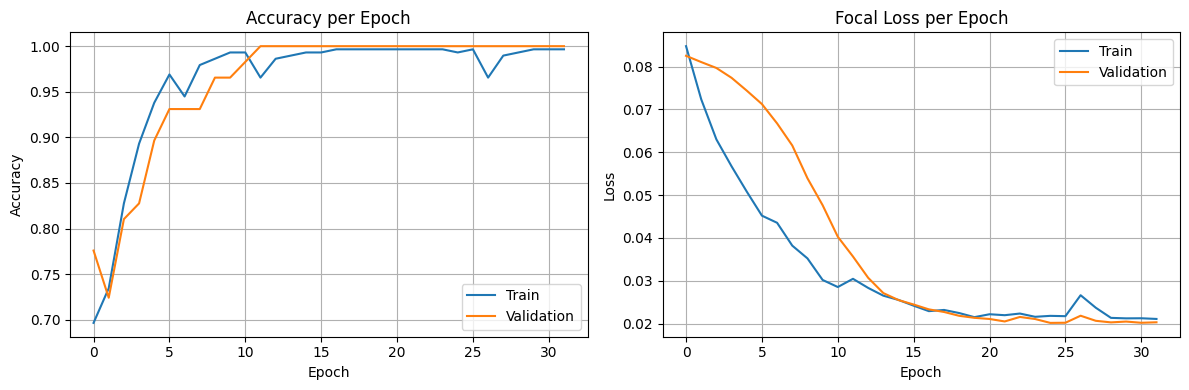

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Focal Loss per Epoch')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()

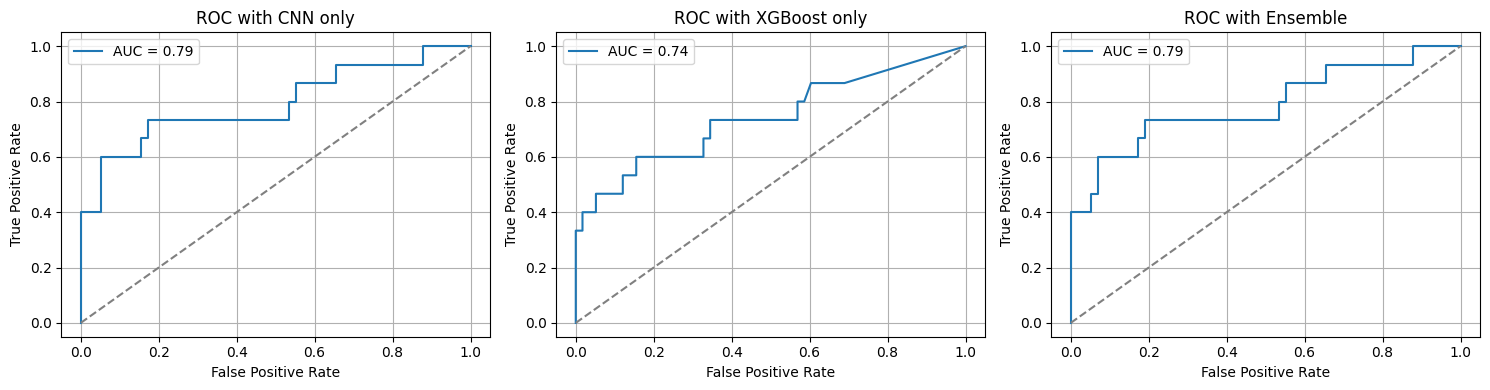

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, probs) in zip(axes, [
    ('CNN only',     cnn_pred_prob),
    ('XGBoost only', xgb_pred_prob),
    ('Ensemble',     final_pred_prob)
]):
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
    ax.plot([0, 1], [0, 1], '--', color='gray')
    ax.set_title(f"ROC with {name}")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(); ax.grid(True)

plt.tight_layout()
plt.show()

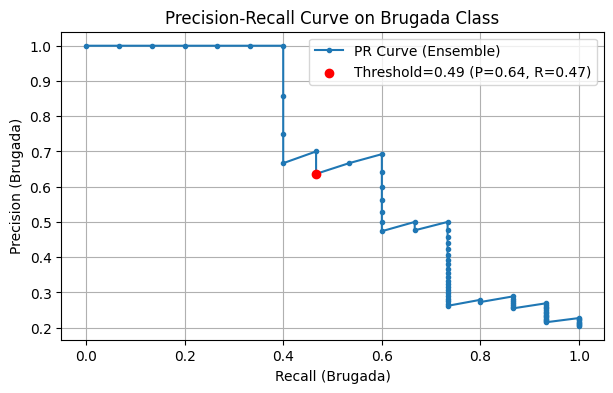

In [ ]:
precisions, recalls, thrs = precision_recall_curve(y_test, final_pred_prob)

plt.figure(figsize=(7, 4))
plt.plot(recalls, precisions, marker='.', label='PR Curve (Ensemble)')

if len(thrs) > 0:
    idx = np.argmin(np.abs(thrs - FINAL_THRESHOLD))
    plt.scatter(
        [recalls[idx]], [precisions[idx]], color='red', zorder=5,
        label=f'Threshold={FINAL_THRESHOLD:.2f} '
              f'(P={precisions[idx]:.2f}, R={recalls[idx]:.2f})'
    )

plt.xlabel('Recall (Brugada)')
plt.ylabel('Precision (Brugada)')
plt.title('Precision-Recall Curve on Brugada Class')
plt.legend(); plt.grid(True)
plt.show()

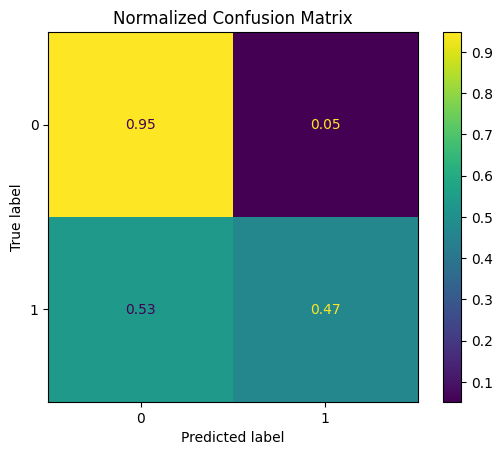

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, final_pred, normalize='true')

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format=".2f")

plt.title("Normalized Confusion Matrix")
plt.show()

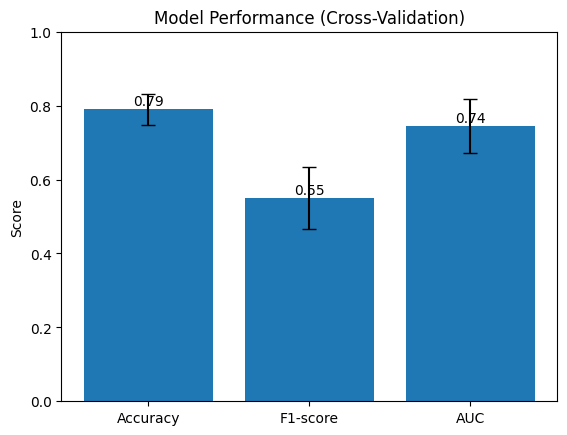

In [ ]:
# Ambil dari hasil K-Fold
acc = [r['acc'] for r in fold_results]
f1  = [r['f1'] for r in fold_results]
auc = [r['auc'] for r in fold_results]

metrics = ['Accuracy', 'F1-score', 'AUC']
means   = [np.mean(acc), np.mean(f1), np.mean(auc)]
stds    = [np.std(acc), np.std(f1), np.std(auc)]

plt.figure()
plt.bar(metrics, means, yerr=stds, capsize=5)

plt.title("Model Performance (Cross-Validation)")
plt.ylabel("Score")

for i, v in enumerate(means):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.ylim(0, 1)
plt.show()

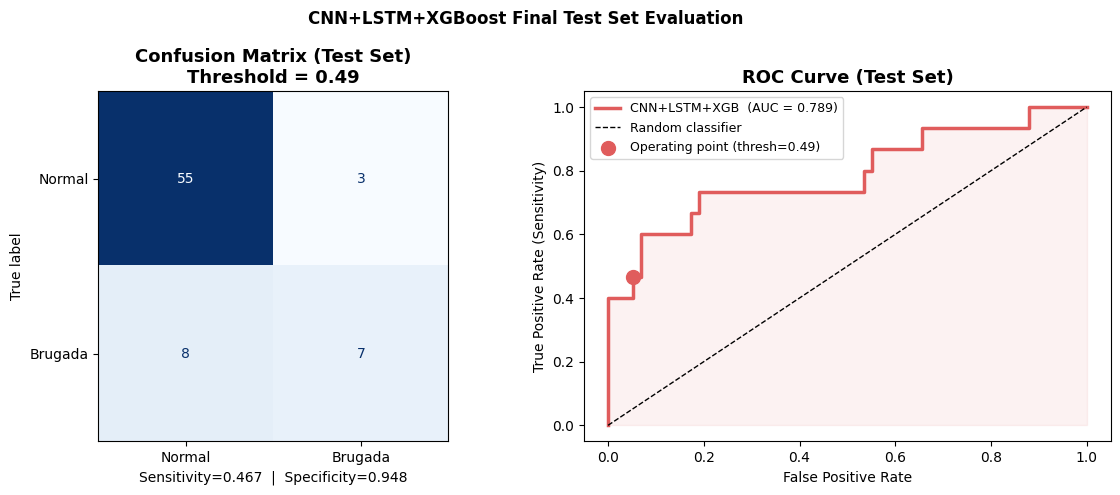

viz_fig1_eval.png


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Confusion Matrix ───
cm   = confusion_matrix(y_test, final_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Normal", "Brugada"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title(
    f"Confusion Matrix (Test Set)\nThreshold = {FINAL_THRESHOLD:.2f}",
    fontweight="bold", fontsize=13
)

tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
axes[0].set_xlabel(
    f"Sensitivity={sensitivity:.3f}  |  Specificity={specificity:.3f}",
    fontsize=10
)

# ── ROC Curve ─
fpr, tpr, _ = roc_curve(y_test, final_pred_prob)
roc_auc     = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color="#E05C5C", linewidth=2.5,
             label=f"CNN+LSTM+XGB  (AUC = {roc_auc:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", linewidth=1, label="Random classifier")
axes[1].fill_between(fpr, tpr, alpha=0.08, color="#E05C5C")
axes[1].scatter([1 - specificity], [sensitivity],
                color="#E05C5C", s=100, zorder=5,
                label=f"Operating point (thresh={FINAL_THRESHOLD:.2f})")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate (Sensitivity)")
axes[1].set_title("ROC Curve (Test Set)", fontweight="bold", fontsize=13)
axes[1].legend(fontsize=9)

plt.suptitle("CNN+LSTM+XGBoost Final Test Set Evaluation",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/viz_fig1_eval.png", bbox_inches="tight", dpi=150)
plt.show()
print("viz_fig1_eval.png")

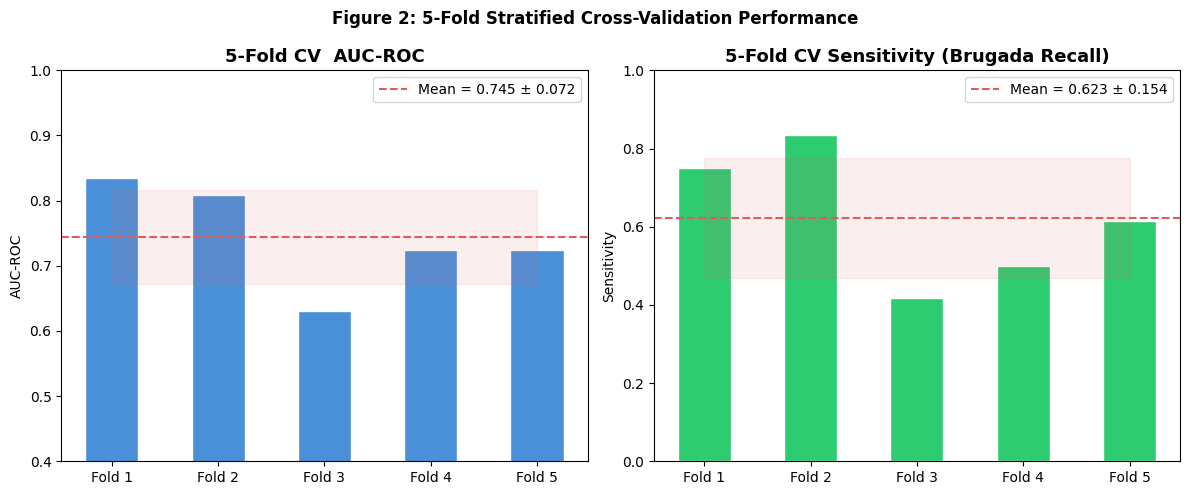

✅ Saved: viz_fig2_cv.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

folds     = [f"Fold {i+1}" for i in range(5)]
auc_vals  = [r["auc"] for r in fold_results]
f1_vals   = [r["f1"]  for r in fold_results]
rec_vals  = [r["recall"] for r in fold_results]

# AUC per fold
axes[0].bar(folds, auc_vals, color="#4A90D9", width=0.5, edgecolor="white")
axes[0].axhline(np.mean(auc_vals), color="#E05C5C", linestyle="--", linewidth=1.5,
                label=f"Mean = {np.mean(auc_vals):.3f} ± {np.std(auc_vals):.3f}")
axes[0].fill_between(range(5),
                     np.mean(auc_vals) - np.std(auc_vals),
                     np.mean(auc_vals) + np.std(auc_vals),
                     alpha=0.1, color="#E05C5C")
axes[0].set_ylim(0.4, 1.0)
axes[0].set_title("5-Fold CV  AUC-ROC", fontweight="bold", fontsize=13)
axes[0].set_ylabel("AUC-ROC")
axes[0].legend()

# Sensitivity (Recall Brugada) per fold
axes[1].bar(folds, rec_vals, color="#2ECC71", width=0.5, edgecolor="white")
axes[1].axhline(np.mean(rec_vals), color="#E05C5C", linestyle="--", linewidth=1.5,
                label=f"Mean = {np.mean(rec_vals):.3f} ± {np.std(rec_vals):.3f}")
axes[1].fill_between(range(5),
                     np.mean(rec_vals) - np.std(rec_vals),
                     np.mean(rec_vals) + np.std(rec_vals),
                     alpha=0.1, color="#E05C5C")
axes[1].set_ylim(0.0, 1.0)
axes[1].set_title("5-Fold CV Sensitivity (Brugada Recall)",
                  fontweight="bold", fontsize=13)
axes[1].set_ylabel("Sensitivity")
axes[1].legend()

plt.suptitle("Figure 2: 5-Fold Stratified Cross-Validation Performance",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/viz_fig2_cv.png", bbox_inches="tight", dpi=150)
plt.show()
print("viz_fig2_cv.png")

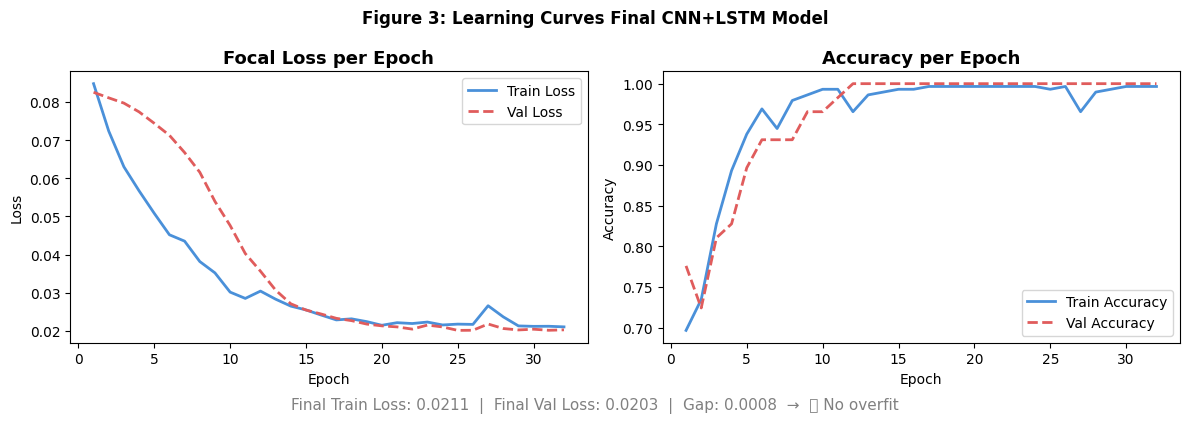

✅ Saved: viz_fig3_learning.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, len(history.history["loss"]) + 1)

# Loss
axes[0].plot(epochs, history.history["loss"],
             color="#4A90D9", linewidth=2, label="Train Loss")
axes[0].plot(epochs, history.history["val_loss"],
             color="#E05C5C", linewidth=2, linestyle="--", label="Val Loss")
axes[0].set_title("Focal Loss per Epoch", fontweight="bold", fontsize=13)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Accuracy
axes[1].plot(epochs, history.history["accuracy"],
             color="#4A90D9", linewidth=2, label="Train Accuracy")
axes[1].plot(epochs, history.history["val_accuracy"],
             color="#E05C5C", linewidth=2, linestyle="--", label="Val Accuracy")
axes[1].set_title("Accuracy per Epoch", fontweight="bold", fontsize=13)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

# Annotate final values
final_tl = history.history["loss"][-1]
final_vl = history.history["val_loss"][-1]
gap      = abs(final_tl - final_vl)
verdict  = "No overfit" if gap < 0.05 else (" Mild overfit" if gap < 0.15 else " Overfit")
fig.text(0.5, -0.02,
         f"Final Train Loss: {final_tl:.4f}  |  Final Val Loss: {final_vl:.4f}  |  Gap: {gap:.4f}  →  {verdict}",
         ha="center", fontsize=11, color="gray")

plt.suptitle("Figure 3: Learning Curves Final CNN+LSTM Model",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/viz_fig3_learning.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: viz_fig3_learning.png")

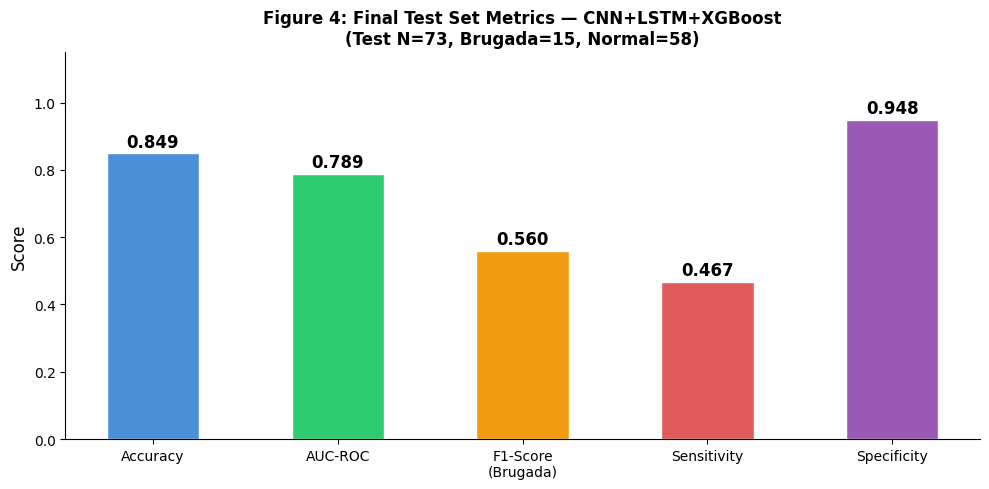

✅ Saved: viz_fig4_metrics.png


In [ ]:
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score

tn, fp, fn, tp = confusion_matrix(y_test, final_pred).ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
f1          = f1_score(y_test, final_pred)
roc_auc_val = roc_auc_score(y_test, final_pred_prob)
accuracy    = accuracy_score(y_test, final_pred)

metrics_names = ["Accuracy", "AUC-ROC", "F1-Score\n(Brugada)",
                 "Sensitivity", "Specificity"]
metrics_vals  = [accuracy, roc_auc_val, f1, sensitivity, specificity]
colors        = ["#4A90D9", "#2ECC71", "#F39C12", "#E05C5C", "#9B59B6"]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(metrics_names, metrics_vals, color=colors,
              width=0.5, edgecolor="white")

for bar, val in zip(bars, metrics_vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.02,
            f"{val:.3f}", ha="center", fontsize=12, fontweight="bold")

ax.set_ylim(0, 1.15)
ax.set_ylabel("Score", fontsize=12)
ax.set_title(
    f"Figure 4: Final Test Set Metrics — CNN+LSTM+XGBoost\n"
    f"(Test N={len(y_test)}, Brugada={y_test.sum()}, Normal={(y_test==0).sum()})",
    fontweight="bold", fontsize=12
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("/content/viz_fig4_metrics.png", bbox_inches="tight", dpi=150)
plt.show()
print(" viz_fig4_metrics.png")